In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
plt.rcParams['figure.figsize'] = (12, 6)


In [4]:
df = pd.read_csv("C:\\Users\\Karth\\OneDrive\\Desktop\\KM\\Data Analytics\\train.csv", parse_dates=['date'])
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [10]:
df.describe

<bound method NDFrame.describe of               id       date  store_nbr                      family     sales  \
0              0 2013-01-01          1                  AUTOMOTIVE     0.000   
1              1 2013-01-01          1                   BABY CARE     0.000   
2              2 2013-01-01          1                      BEAUTY     0.000   
3              3 2013-01-01          1                   BEVERAGES     0.000   
4              4 2013-01-01          1                       BOOKS     0.000   
...          ...        ...        ...                         ...       ...   
3000883  3000883 2017-08-15          9                     POULTRY   438.133   
3000884  3000884 2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885 2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886 2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887 2017-08-15          9                     SEAFOOD    16.000   

     

In [12]:
df.shape

(3000888, 6)

In [5]:
#Examine date range
print(f"start date: {df['date'].min()}")
print(f"end date: {df['date'].max()}")
time_span=df['date'].max() - df['date'].min()
print(f"time span: {time_span.days} days ({time_span.days/365:.1f} years)")

start date: 2013-01-01 00:00:00
end date: 2017-08-15 00:00:00
time span: 1687 days (4.6 years)


In [6]:
#Aggregate data by date
daily_sales=df.groupby('date')['sales'].sum().reset_index()
daily_sales.columns=['date','total_sales']
daily_sales= daily_sales.sort_values('date').reset_index(drop=True)
print(f"Daily aggregate records:{len(daily_sales)}")
daily_sales.head(10)

Daily aggregate records:1684


,date,total_sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229
5,2013-01-06,519695.401088
6,2013-01-07,336122.801066
7,2013-01-08,318347.777981
8,2013-01-09,302530.809018
9,2013-01-10,258982.003049


In [7]:
ts_data=daily_sales.copy()
ts_data.set_index('date', inplace=True)
ts_data.head()

,total_sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229


In [8]:
ts_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1684 entries, 2013-01-01 to 2017-08-15
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   total_sales  1684 non-null   float64
dtypes: float64(1)
memory usage: 26.3 KB


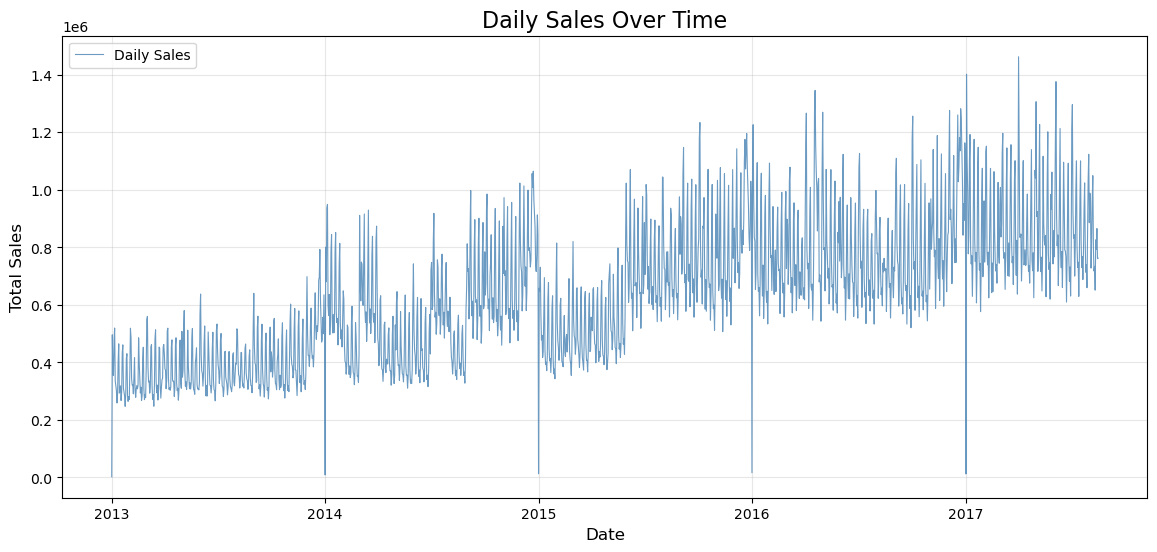

In [9]:
plt.figure(figsize=(14,6))
plt.plot(ts_data.index, ts_data['total_sales'], color='steelblue',linewidth=0.8,alpha=0.8, label='Daily Sales')
plt.title('Daily Sales Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

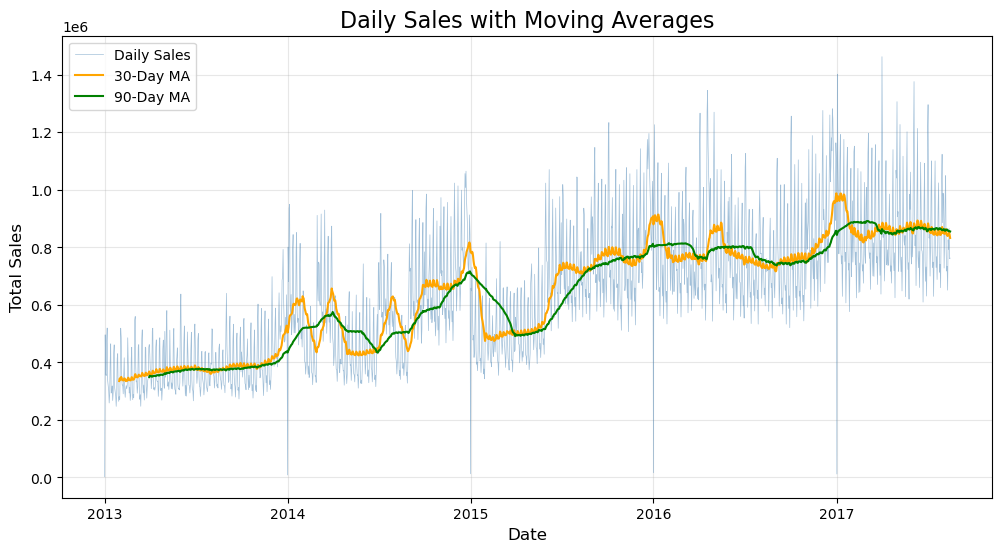

In [10]:
# Add moving average to watch trends and smooth out short-term fluctuations

ts_data['MA_30']=ts_data['total_sales'].rolling(window=30).mean()
ts_data['MA_90']=ts_data['total_sales'].rolling(window=90).mean()
plt.plot(ts_data.index, ts_data['total_sales'], color='steelblue',linewidth=0.5,alpha=0.5, label='Daily Sales')
plt.plot(ts_data.index, ts_data['MA_30'], color='orange', linewidth=1.5, label='30-Day MA')
plt.plot(ts_data.index, ts_data['MA_90'], color='green', linewidth=1.5, label='90-Day MA')
plt.title('Daily Sales with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

              total_sales  MA_30  MA_90  month  year
date                                                
2013-01-01    2511.618999    NaN    NaN      1  2013
2013-01-02  496092.417944    NaN    NaN      1  2013
2013-01-03  361461.231124    NaN    NaN      1  2013
2013-01-04  354459.677093    NaN    NaN      1  2013
2013-01-05  477350.121229    NaN    NaN      1  2013


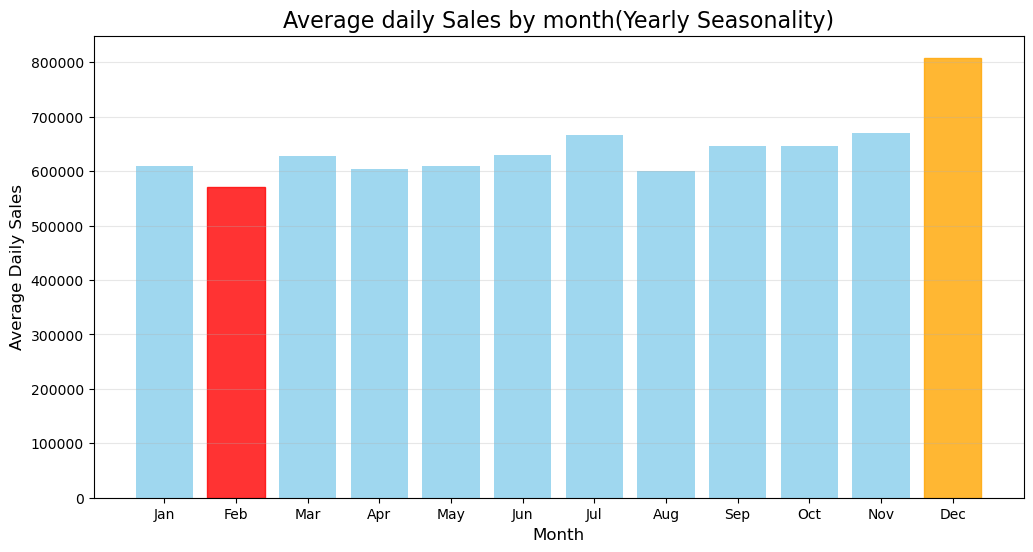

In [12]:
# Analyse monthly patterns (seasonality)
# crearte monthly column from date index
monthly_pattern = ts_data.copy()
monthly_pattern['month'] = monthly_pattern.index.month
monthly_pattern['year'] = monthly_pattern.index.year
print(monthly_pattern.head())
monthly_avg = monthly_pattern.groupby('month')['total_sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bars=plt.bar(range(1,13),monthly_avg.values, color='skyblue',alpha=0.8)
#highlight highest and lowest months
max_month = monthly_avg.idxmax()
min_month = monthly_avg.idxmin()
bars[max_month-1].set_color('orange')
bars[min_month-1].set_color('red')
plt.title('Average daily Sales by month(Yearly Seasonality)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Daily Sales', fontsize=12)
plt.xticks(range(1,13), month_names)
plt.grid(alpha=0.3, axis='y')
plt.show()

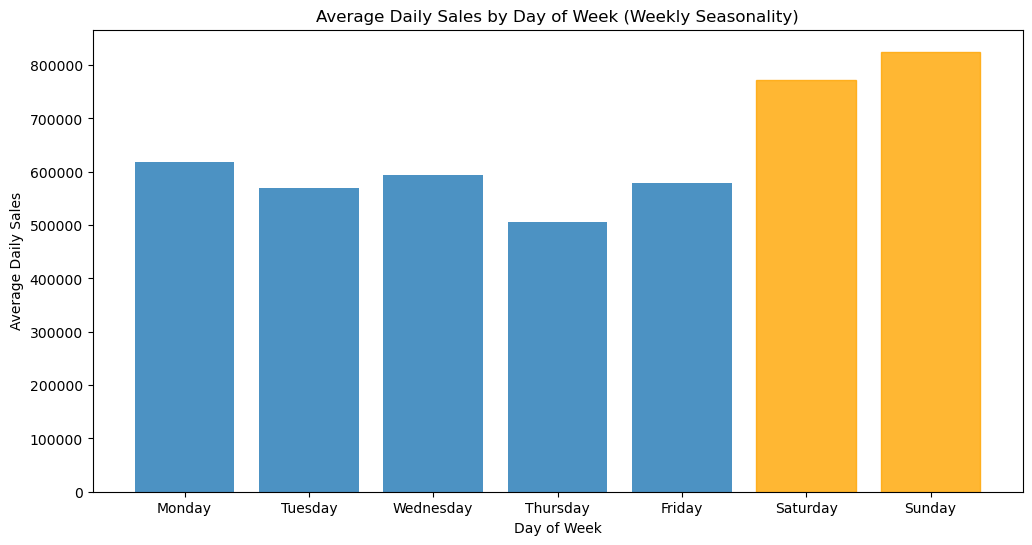

In [13]:
#Analyse day of week patterns (weekly seasonality)
weekly_pattern = ts_data.copy()
weekly_pattern['day_of_week'] = weekly_pattern.index.dayofweek  
# Caluclate average sales by day of week

weekly_avg = weekly_pattern.groupby('day_of_week')['total_sales'].mean()
 
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
 
bars = plt.bar(range(7), weekly_avg.values, alpha=0.8)

# Highlight highest and lowest months
 
bars[5].set_color('orange')

bars[6].set_color('orange')

plt.title('Average Daily Sales by Day of Week (Weekly Seasonality)')

plt.xlabel('Day of Week')

plt.ylabel('Average Daily Sales')

plt.xticks(range(7), day_names)

plt.show()
 

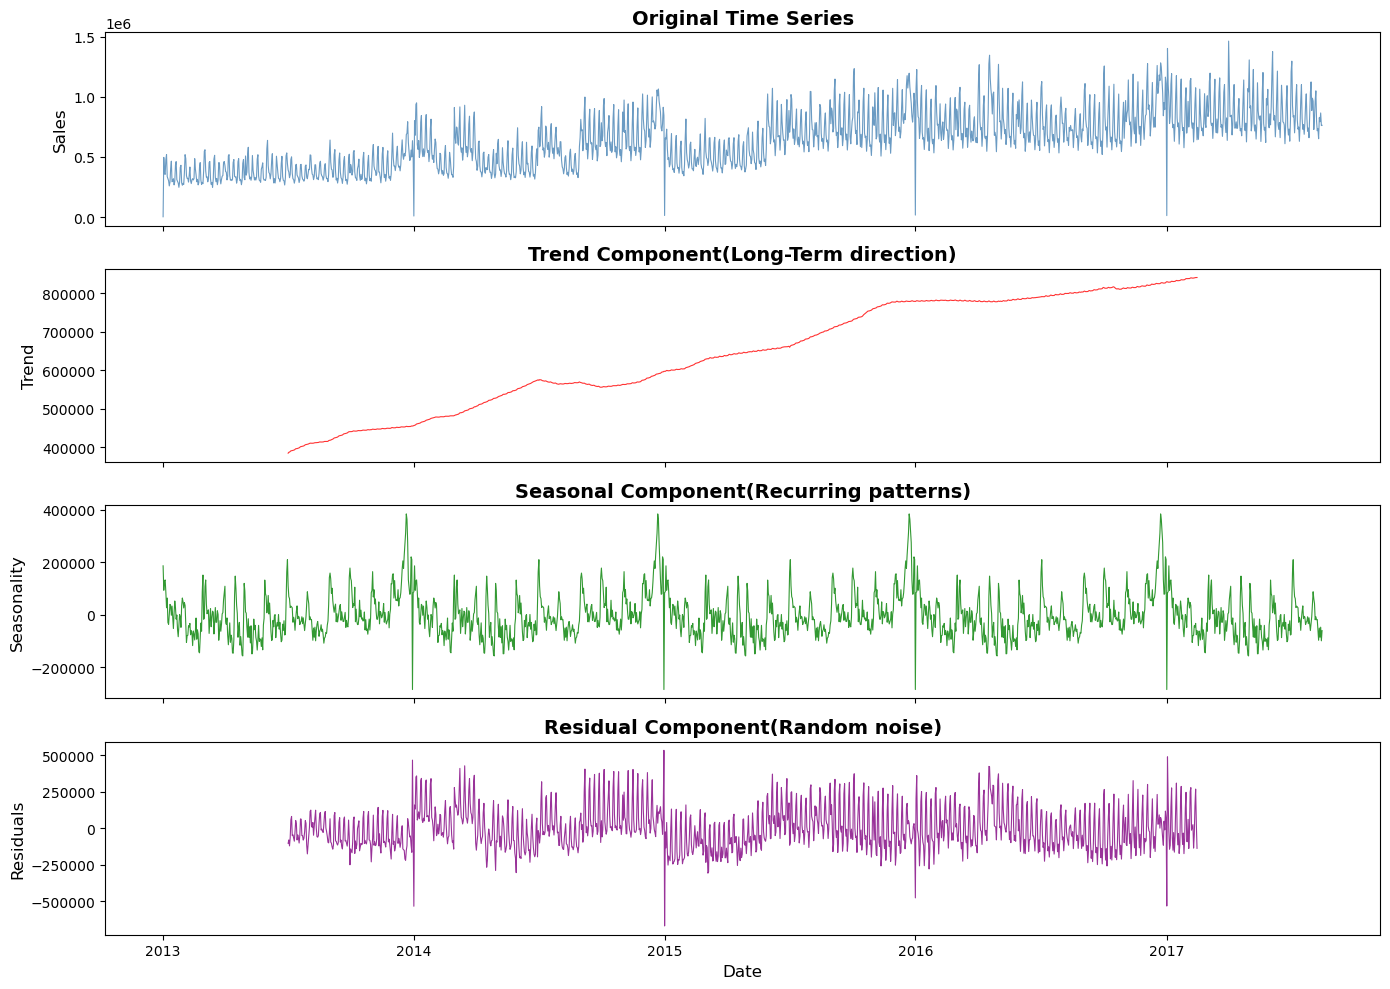

In [14]:
# perform time series decomposition to extract trend, seasonality and residuals
decomposition = seasonal_decompose(ts_data['total_sales'], model='additive', period=365)
#create 4 panel plot to show original, trend, seasonality and residuals
fig,axes=plt.subplots(4,1, figsize=(14,10), sharex=True)

#panel 1 -original data
axes[0].plot(ts_data.index, ts_data['total_sales'], color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].set_title('Original Time Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales', fontsize=12)

#panel 2 -trend
axes[1].plot(decomposition.trend.index, decomposition.trend, color='red', linewidth=0.8, alpha=0.8)
axes[1].set_title('Trend Component(Long-Term direction)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend', fontsize=12)

#panel 3 -seasonality
axes[2].plot(decomposition.seasonal.index,decomposition.seasonal, color='green', linewidth=0.8, alpha=0.8)
axes[2].set_title('Seasonal Component(Recurring patterns)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonality', fontsize=12)

#panel 4 -residuals
axes[3].plot(decomposition.resid.index, decomposition.resid, color='purple', linewidth=0.8, alpha=0.8)
axes[3].set_title('Residual Component(Random noise)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_ylabel('Residuals', fontsize=12)
plt.tight_layout()
plt.show()


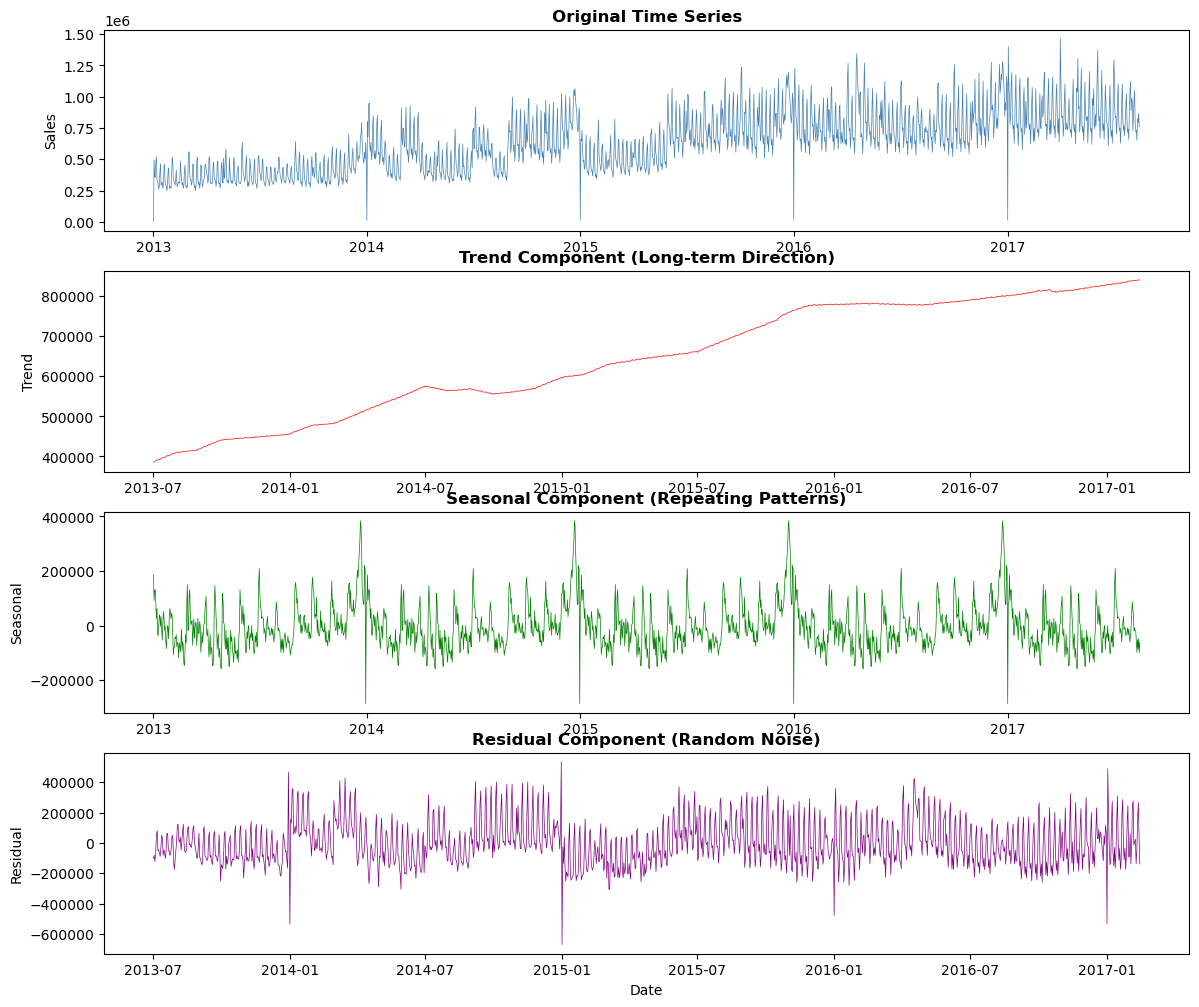

In [15]:
# Perform Time-Series Decomposition
decomposition = seasonal_decompose(ts_data['total_sales'], model='additive', period=365) 
# Create a 4 panel plot showing all components
fig, axes = plt.subplots(4, 1, figsize=(14,12)) 
# Panel 1: Original Data
axes[0].plot(ts_data.index, ts_data['total_sales'], color='steelblue', linewidth=0.5)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales') 
# Panel 2: Trend Component
axes[1].plot(decomposition.trend.index, decomposition.trend, color='red', linewidth=0.5)
axes[1].set_title('Trend Component (Long-term Direction)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend') 
# Panel 3: Seasonal Component
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='green', linewidth=0.5)
axes[2].set_title('Seasonal Component (Repeating Patterns)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal') 
# Panel 3: Residual (Noise)
axes[3].plot(decomposition.resid.index, decomposition.resid, color='purple', linewidth=0.5)
axes[3].set_title('Residual Component (Random Noise)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
plt.show()
 

In [16]:
#Quantify the components by calculating their standard deviation
#original data statistics
original_std = ts_data['total_sales'].std()
print(f"Original Data Standard Deviation: {original_std:.2f}")
#trend component statistics
trend_std = decomposition.trend.std()
print(f"Trend Component Standard Deviation: {trend_std:.2f}")
#seasonal component statistics
seasonal_std = decomposition.seasonal.std()
print(f"Seasonal Component Standard Deviation: {seasonal_std:.2f}")
#residual component statistics
residual_std = decomposition.resid.std()
print(f"Residual Component Standard Deviation: {residual_std:.2f}")


# Calculate percentage contribution of each component
total_variation = trend_std + seasonal_std + residual_std
print(f"\n--- Relative Importance ---")
print(f"Trend contribution: {(trend_std/total_variation)*100:.1f}%")
print(f"Seasonal contribution: {(seasonal_std/total_variation)*100:.1f}%")
print(f"Residual (noise) contribution: {(residual_std/total_variation)*100:.1f}%")
 

Original Data Standard Deviation: 234410.24
Trend Component Standard Deviation: 136802.14
Seasonal Component Standard Deviation: 82684.66
Residual Component Standard Deviation: 146318.53

--- Relative Importance ---
Trend contribution: 37.4%
Seasonal contribution: 22.6%
Residual (noise) contribution: 40.0%
